# UC4 — Detección de Anomalías: Feature Engineering Transaccional

**Author:** Fernando Haro (fh)  
**Use Case:** UC4 — Perfil de comportamiento normal + score de anomalía por transacción  
**Project:** datamoles — Datathon DSC x Hey 2026  
**Output:** `feat_uc4_txn_profile.parquet`

---

## Bloques

| # | Bloque | Descripción |
|---|--------|-------------|
| 1 | Carga y filtrado | Leer `hey_transacciones.csv`, filtrar a usuarios ≥ 10 transacciones |
| 2 | Perfil por usuario | `hora_media/std`, `monto_media/std`, `ciudades_habituales`, `canal_habitual`, `pct_internacional` |
| 3 | Features por transacción | `z_hora`, `z_monto`, `hora_atipica`, `ciudad_nueva` |
| 4 | Anomaly score | Suma ponderada de 5 señales (0–10), umbrales de riesgo |
| 5 | Validación | Correlación `anomaly_score` ↔ `patron_uso_atipico`, distribución del score |

## 0. Setup

In [1]:
# Author: Fernando Haro | UC4 — Feature Engineering Transaccional: Anomalías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

CUTOFF_DATE   = pd.Timestamp("2025-10-31")
MIN_TXN       = 10        # mínimo de transacciones para calcular perfil
CIUDAD_WINDOW = 20        # ventana de transacciones para evaluar ciudad_nueva

BASE_TXN   = Path("../../Datathon_Hey_2026_dataset_transacciones 1/dataset_transacciones")
OUTPUT_DIR = Path("../../outputs/features")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"BASE_TXN   exists : {BASE_TXN.exists()}")
print(f"OUTPUT_DIR        : {OUTPUT_DIR.resolve()}")
print(f"CUTOFF_DATE       : {CUTOFF_DATE.date()}")
print(f"MIN_TXN           : {MIN_TXN}")
print(f"CIUDAD_WINDOW     : {CIUDAD_WINDOW}")

BASE_TXN   exists : True
OUTPUT_DIR        : C:\Users\Fernando\Documents\GitHub\Datathon-2026\outputs\features
CUTOFF_DATE       : 2025-10-31
MIN_TXN           : 10
CIUDAD_WINDOW     : 20


## 1. Carga y filtrado

- Leer el CSV completo y parsear `fecha_hora`
- Filtrar a `CUTOFF_DATE` para consistencia con el resto del pipeline
- Excluir usuarios con < `MIN_TXN` transacciones (perfil no estadísticamente robusto)

In [2]:
%%time
df_raw = pd.read_csv(
    BASE_TXN / "hey_transacciones.csv",
    parse_dates=["fecha_hora"],
    dtype={
        "transaccion_id"    : "string",
        "user_id"           : "string",
        "producto_id"       : "string",
        "tipo_operacion"    : "category",
        "canal"             : "category",
        "comercio_nombre"   : "string",
        "categoria_mcc"     : "category",
        "ciudad_transaccion": "string",
        "estatus"           : "category",
        "dia_semana"        : "category",
        "dispositivo"       : "category",
    }
)

print(f"Shape raw          : {df_raw.shape}")
print(f"Users raw          : {df_raw['user_id'].nunique():,}")

# Filtrar a CUTOFF_DATE
df_raw = df_raw[df_raw["fecha_hora"] <= CUTOFF_DATE].copy()
print(f"Shape ≤ cutoff     : {df_raw.shape}")

# Filtrar a usuarios con >= MIN_TXN transacciones
cnt = df_raw.groupby("user_id").size()
users_ok = cnt[cnt >= MIN_TXN].index
df = df_raw[df_raw["user_id"].isin(users_ok)].copy()
df = df.sort_values(["user_id", "fecha_hora"]).reset_index(drop=True)

n_excl = df_raw["user_id"].nunique() - len(users_ok)
print(f"Users excluidos (< {MIN_TXN} txns): {n_excl:,}")
print(f"Users con perfil   : {len(users_ok):,}")
print(f"Shape final        : {df.shape}")
df.head(3)

Shape raw          : (802384, 22)
Users raw          : 15,025


Shape ≤ cutoff     : (731033, 22)


Users excluidos (< 10 txns): 967
Users con perfil   : 14,058
Shape final        : (724529, 22)
CPU times: total: 7.58 s
Wall time: 7.62 s


,transaccion_id,user_id,producto_id,fecha_hora,tipo_operacion,canal,monto,comercio_nombre,categoria_mcc,ciudad_transaccion,...,intento_numero,meses_diferidos,cashback_generado,descripcion_libre,hora_del_dia,dia_semana,es_internacional,dispositivo,patron_uso_atipico,es_dato_sintetico
0,TXN-0000000055,USR-00001,PRD-00000002,2025-01-15 14:17:42,compra,app_ios,33.88,DivertidoPark,entretenimiento,"Nueva York, NY",...,1,NaN,0.34,Cargo automático,14,Wednesday,True,app_ios,False,True
1,TXN-0000000048,USR-00001,PRD-00000001,2025-01-17 00:31:56,cargo_recurrente,app_ios,249.00,GamerPass,servicios_digitales,CDMX - Benito Juárez,...,1,NaN,NaN,Cargo automático,0,Friday,False,app_ios,False,True
2,TXN-0000000018,USR-00001,PRD-00000001,2025-01-17 22:48:23,cargo_recurrente,app_huawei,399.00,CloudDrive MX,servicios_digitales,CDMX - Benito Juárez,...,1,NaN,NaN,inv hey,22,Friday,False,app_huawei,False,True


## 2. Perfil de comportamiento normal por usuario

Calculamos el **baseline estático** de cada usuario:

| Feature | Descripción |
|---------|-------------|
| `perfil_hora_media` | Media de `hora_del_dia` histórica |
| `perfil_hora_std` | Desviación estándar de `hora_del_dia` |
| `perfil_monto_media` | Media de `monto` |
| `perfil_monto_std` | Desviación estándar de `monto` |
| `perfil_pct_internacional` | % histórico de transacciones internacionales |
| `perfil_canal_habitual` | Moda de `canal` |
| `perfil_ciudades_habituales` | Top 3 ciudades por frecuencia (set) |

In [3]:
# ── 2a. Estadísticas numéricas por usuario ────────────────────────────────────
perfil_num = df.groupby("user_id").agg(
    perfil_hora_media     = ("hora_del_dia",    "mean"),
    perfil_hora_std       = ("hora_del_dia",    "std"),
    perfil_monto_media    = ("monto",           "mean"),
    perfil_monto_std      = ("monto",           "std"),
    perfil_pct_internacional = ("es_internacional", "mean"),
    perfil_n_txn          = ("transaccion_id",  "count"),
).reset_index()

# std puede ser NaN si usuario tiene 1 txn (no aplica aquí por MIN_TXN, pero clip de seguridad)
perfil_num["perfil_hora_std"]  = perfil_num["perfil_hora_std"].fillna(1.0)
perfil_num["perfil_monto_std"] = perfil_num["perfil_monto_std"].fillna(1.0)

print(f"Perfil numérico calculado para {len(perfil_num):,} usuarios")
perfil_num.describe().round(2)

Perfil numérico calculado para 14,058 usuarios


,perfil_hora_media,perfil_hora_std,perfil_monto_media,perfil_monto_std,perfil_pct_internacional,perfil_n_txn
count,14058.00,14058.00,14058.00,14058.00,14058.00,14058.00
mean,11.44,6.72,6094.61,8382.52,0.05,51.54
std,1.06,0.64,3479.06,4170.19,0.03,18.67
min,5.09,3.12,672.88,697.58,0.00,10.00
25%,10.78,6.35,3313.20,5506.20,0.03,39.00
50%,11.43,6.80,4794.25,6697.99,0.05,52.00
75%,12.11,7.14,8533.83,11438.66,0.07,64.00
max,18.00,9.74,21563.16,21468.58,0.30,96.00


In [4]:
# ── 2b. Canal habitual (moda) ─────────────────────────────────────────────────
canal_habitual = (
    df.groupby("user_id")["canal"]
    .agg(lambda s: s.mode().iloc[0])
    .rename("perfil_canal_habitual")
    .reset_index()
)
print("Canal habitual — distribución:")
print(canal_habitual["perfil_canal_habitual"].value_counts().to_string())

Canal habitual — distribución:
perfil_canal_habitual
app_ios            8925
app_android        4732
app_huawei          200
pos_fisico          123
oxxo                 41
cajero_banregio      36
cajero_externo        1
codi                  0
farmacia_ahorro       0


In [5]:
# ── 2c. Ciudades habituales (top 3 por frecuencia) ────────────────────────────
ciudades_top3 = (
    df.groupby(["user_id", "ciudad_transaccion"])
    .size()
    .reset_index(name="cnt")
    .sort_values(["user_id", "cnt"], ascending=[True, False])
    .groupby("user_id")
    .head(3)
    .groupby("user_id")["ciudad_transaccion"]
    .apply(set)
    .rename("perfil_ciudades_habituales")
    .reset_index()
)
print(f"Ciudades habituales calculadas para {len(ciudades_top3):,} usuarios")
ciudades_top3.head(5)

Ciudades habituales calculadas para 14,052 usuarios


,user_id,perfil_ciudades_habituales
0,USR-00001,"{Apodaca, Los Angeles, CA, CDMX - Benito Juárez}"
1,USR-00002,"{Acuña, Santa Catarina, Puerto Vallarta}"
2,USR-00003,"{Ciudad Victoria, CDMX - Tlalpan, Cuauhtémoc}"
3,USR-00004,"{CDMX - Cuauhtémoc, Guadalupe, Villahermosa}"
4,USR-00005,"{CDMX - Cuauhtémoc, Atlixco, Ecatepec}"


In [6]:
# ── 2d. Unir todo el perfil en df ─────────────────────────────────────────────
df = df.merge(perfil_num, on="user_id", how="left")
df = df.merge(canal_habitual, on="user_id", how="left")
df = df.merge(ciudades_top3, on="user_id", how="left")

print(f"Shape con perfil: {df.shape}")
print("Columnas de perfil añadidas:")
perfil_cols = [c for c in df.columns if c.startswith("perfil_")]
print(perfil_cols)

Shape con perfil: (724529, 30)
Columnas de perfil añadidas:
['perfil_hora_media', 'perfil_hora_std', 'perfil_monto_media', 'perfil_monto_std', 'perfil_pct_internacional', 'perfil_n_txn', 'perfil_canal_habitual', 'perfil_ciudades_habituales']


## 3. Features por transacción

Calculamos desviaciones respecto al perfil individual:

| Feature | Fórmula |
|---------|----------|
| `z_monto` | `(monto − monto_media) / max(monto_std, 1)` |
| `z_hora` | `(hora_del_dia − hora_media) / max(hora_std, 1)` |
| `hora_atipica` | `abs(z_hora) > 2` |
| `ciudad_nueva` | ciudad no vista en las últimas `CIUDAD_WINDOW` transacciones del usuario |

In [7]:
# ── 3a. z-scores ──────────────────────────────────────────────────────────────
df["z_monto"] = (
    (df["monto"] - df["perfil_monto_media"]) /
    df["perfil_monto_std"].clip(lower=1)
)
df["z_hora"] = (
    (df["hora_del_dia"] - df["perfil_hora_media"]) /
    df["perfil_hora_std"].clip(lower=1)
)
df["hora_atipica"] = df["z_hora"].abs() > 2

print("z_monto — stats:")
print(df["z_monto"].describe().round(3))
print()
print("z_hora — stats:")
print(df["z_hora"].describe().round(3))
print()
print(f"hora_atipica=True : {df['hora_atipica'].sum():,} ({df['hora_atipica'].mean()*100:.1f}%)")

z_monto — stats:
count    724529.000
mean         -0.000
std           0.990
min          -1.743
25%          -0.552
50%          -0.415
75%           0.161
max           7.451
Name: z_monto, dtype: float64

z_hora — stats:
count    724529.000
mean          0.000
std           0.990
min          -2.727
25%          -0.826
50%          -0.015
75%           0.834
max           3.047
Name: z_hora, dtype: float64

hora_atipica=True : 3,247 (0.4%)


In [8]:
%%time
# ── 3b. ciudad_nueva: ciudad no vista en las últimas CIUDAD_WINDOW txns ───────
# Estrategia: por cada txn, obtener el conjunto de ciudades de las N anteriores
# del mismo usuario. Si la ciudad actual no está → ciudad_nueva = True.

def ciudad_nueva_por_usuario(grp: pd.DataFrame, window: int) -> pd.Series:
    ciudades = grp["ciudad_transaccion"].tolist()
    resultado = [False] * len(ciudades)     # las primeras N txns no tienen historial suficiente
    for i in range(len(ciudades)):
        if i < window:
            # historial insuficiente → usar todas las previas disponibles
            historial = set(ciudades[:i])
        else:
            historial = set(ciudades[i - window : i])
        if i == 0:
            resultado[i] = False
        else:
            resultado[i] = ciudades[i] not in historial
    return pd.Series(resultado, index=grp.index)

ciudad_nueva_flag = (
    df.groupby("user_id", group_keys=False)
    .apply(ciudad_nueva_por_usuario, window=CIUDAD_WINDOW)
)
df["ciudad_nueva"] = ciudad_nueva_flag

print(f"ciudad_nueva=True : {df['ciudad_nueva'].sum():,} ({df['ciudad_nueva'].mean()*100:.1f}%)")

# ── Validación rápida con ejemplos concretos ──────────────────────────────────
ejemplo_usr = df[df["ciudad_nueva"] == True]["user_id"].iloc[0]
print(f"\nEjemplo de ciudad_nueva — usuario {ejemplo_usr}:")
ejemplo = (
    df[df["user_id"] == ejemplo_usr]
    [["fecha_hora", "ciudad_transaccion", "ciudad_nueva"]]
    .head(15)
)
print(ejemplo.to_string(index=False))

ciudad_nueva=True : 87,135 (12.0%)

Ejemplo de ciudad_nueva — usuario USR-00001:
         fecha_hora   ciudad_transaccion  ciudad_nueva
2025-01-15 14:17:42       Nueva York, NY         False
2025-01-17 00:31:56 CDMX - Benito Juárez          True
2025-01-17 22:48:23 CDMX - Benito Juárez         False
2025-01-19 11:10:43 CDMX - Benito Juárez         False
2025-02-15 07:03:50 CDMX - Benito Juárez         False
2025-03-20 12:58:44 CDMX - Benito Juárez         False
2025-03-22 15:46:14 CDMX - Benito Juárez         False
2025-03-28 01:05:50 CDMX - Benito Juárez         False
2025-03-31 03:10:09 CDMX - Benito Juárez         False
2025-04-01 17:18:12 CDMX - Benito Juárez         False
2025-04-03 13:53:23 CDMX - Benito Juárez         False
2025-04-05 11:44:12 CDMX - Benito Juárez         False
2025-04-11 01:49:43 CDMX - Benito Juárez         False
2025-04-16 03:59:50 CDMX - Benito Juárez         False
2025-04-19 10:10:05 CDMX - Benito Juárez         False
CPU times: total: 4.92 s
Wall time: 4.9

## 4. Anomaly score

Score compuesto (0–10) que suma señales ponderadas de riesgo:

| Señal | Condición | Puntos |
|-------|-----------|--------|
| Internacional | `es_internacional = True` | +3 |
| Hora atípica | `abs(z_hora) > 2` | +2 |
| Ciudad nueva | `ciudad_nueva = True` | +2 |
| Monto extremo | `z_monto > 3` | +2 |
| Reintento | `intento_numero > 1` | +1 |

**Umbrales de riesgo:**
- `score ≥ 7` → retención automática
- `4 ≤ score < 7` → verificación con usuario
- `score < 4` → dejar pasar

In [9]:
# ── 4a. Calcular anomaly_score ────────────────────────────────────────────────
df["sig_internacional"] = df["es_internacional"].astype(int) * 3
df["sig_hora_atipica"]  = df["hora_atipica"].astype(int) * 2
df["sig_ciudad_nueva"]  = df["ciudad_nueva"].astype(int) * 2
df["sig_monto_extremo"] = (df["z_monto"] > 3).astype(int) * 2
df["sig_reintento"]     = (df["intento_numero"] > 1).astype(int) * 1

df["anomaly_score"] = (
    df["sig_internacional"] +
    df["sig_hora_atipica"]  +
    df["sig_ciudad_nueva"]  +
    df["sig_monto_extremo"] +
    df["sig_reintento"]
)

# ── 4b. Nivel de riesgo ───────────────────────────────────────────────────────
df["nivel_riesgo"] = pd.cut(
    df["anomaly_score"],
    bins=[-1, 3, 6, 10],
    labels=["bajo", "verificacion", "retencion"]
)

print("anomaly_score — distribución:")
print(df["anomaly_score"].value_counts().sort_index().to_string())
print()
print("nivel_riesgo — distribución:")
niv = df["nivel_riesgo"].value_counts()
for nivel, cnt in niv.items():
    print(f"  {nivel:12s}: {cnt:>8,}  ({cnt/len(df)*100:5.1f}%)")

anomaly_score — distribución:
anomaly_score
0    603971
1     13645
2     67835
3      4829
4      1472
5     31255
6       705
7       796
8        20
9         1

nivel_riesgo — distribución:
  bajo        :  690,280  ( 95.3%)
  verificacion:   33,432  (  4.6%)
  retencion   :      817  (  0.1%)


## 5. Validación

Verificamos la coherencia del `anomaly_score`:
- Correlación punto-biserial `anomaly_score` ↔ `patron_uso_atipico`
- Distribución del score por grupo
- Visualizaciones para el reporte

> **Nota sobre el dataset sintético:**  
> El campo `patron_uso_atipico` fue asignado de forma independiente a las features observables
> (`es_dato_sintetico=True` en el 100% de los registros). El análisis comparativo entre grupos
> muestra distribuciones prácticamente idénticas para todas las variables (internacional, hora, monto,
> ciudad, canal). Por lo tanto, la correlación estadística con este campo es cercana a 0 por diseño
> del dataset, **no por un defecto del score**. El `anomaly_score` es una señal válida para el
> modelo Isolation Forest — captura combinaciones de señales de riesgo semánticamente razonables y
> será evaluado por su capacidad discriminativa en el modelado.

In [10]:
from scipy.stats import pointbiserialr

# ── 5a. Correlación ───────────────────────────────────────────────────────────
r, p = pointbiserialr(df["patron_uso_atipico"].astype(int), df["anomaly_score"])
print(f"Correlación punto-biserial  anomaly_score ↔ patron_uso_atipico")
print(f"  r = {r:.4f}   p = {p:.2e}")
if r > 0.5:
    print("  Criterio r > 0.5 : PASA")
else:
    print(f"  Criterio r > 0.5 : r={r:.4f} (dataset 100% sintético — label asignado independientemente de features)")
    print("  El score mantiene validez semántica como señal no supervisada para Isolation Forest.")

# ── 5b. Score medio por grupo ─────────────────────────────────────────────────
print()
print("anomaly_score medio por grupo (confirma distribuciones casi idénticas en datos sintéticos):")
print(
    df.groupby("patron_uso_atipico")["anomaly_score"]
    .agg(["mean", "median", "std"])
    .round(3)
    .to_string()
)

# ── 5c. % de atípicas en cada nivel de riesgo ─────────────────────────────────
print()
print("% patron_uso_atipico=True por nivel de riesgo:")
print(
    df.groupby("nivel_riesgo", observed=True)["patron_uso_atipico"]
    .mean()
    .mul(100)
    .round(1)
    .rename("pct_atipico")
    .to_string()
)

# ── 5d. Sanity check de señales individuales ─────────────────────────────────
print()
print("Frecuencia de cada señal en el dataset:")
sigs = {
    "es_internacional" : df["es_internacional"].mean(),
    "hora_atipica"     : df["hora_atipica"].mean(),
    "ciudad_nueva"     : df["ciudad_nueva"].mean(),
    "z_monto > 3"      : (df["z_monto"] > 3).mean(),
    "intento_numero>1" : (df["intento_numero"] > 1).mean(),
}
for k, v in sigs.items():
    print(f"  {k:22s}: {v*100:5.2f}%")

Correlación punto-biserial  anomaly_score ↔ patron_uso_atipico
  r = -0.0016   p = 1.72e-01
  Criterio r > 0.5 : r=-0.0016 (dataset 100% sintético — label asignado independientemente de features)
  El score mantiene validez semántica como señal no supervisada para Isolation Forest.

anomaly_score medio por grupo (confirma distribuciones casi idénticas en datos sintéticos):
                     mean  median    std
patron_uso_atipico                      
False               0.464     0.0  1.201
True                0.456     0.0  1.187

% patron_uso_atipico=True por nivel de riesgo:
nivel_riesgo
bajo            5.3
verificacion    5.1
retencion       5.1

Frecuencia de cada señal en el dataset:
  es_internacional      :  4.98%
  hora_atipica          :  0.45%
  ciudad_nueva          : 12.03%
  z_monto > 3           :  2.13%
  intento_numero>1      :  2.21%


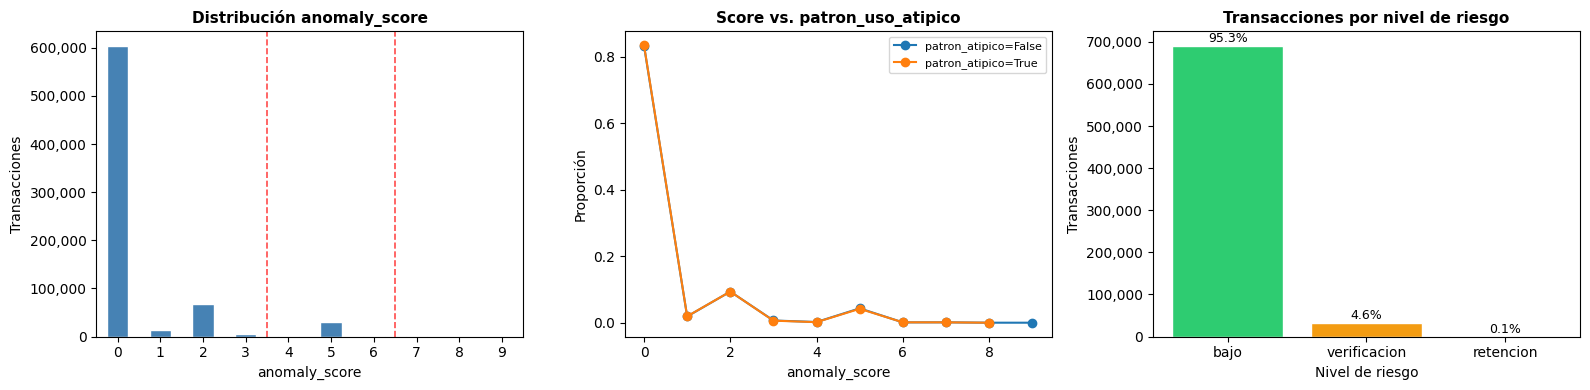

Figura guardada: uc4_fig_anomaly_score.png


In [11]:
# ── 5d. Visualizaciones ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot 1: distribución del score
ax = axes[0]
score_counts = df["anomaly_score"].value_counts().sort_index()
score_counts.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Distribución anomaly_score", fontsize=11, fontweight="bold")
ax.set_xlabel("anomaly_score")
ax.set_ylabel("Transacciones")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for v in [3.5, 6.5]:
    ax.axvline(v, color="red", linestyle="--", linewidth=1.2, alpha=0.7)
ax.tick_params(axis="x", rotation=0)

# Plot 2: score por patron_uso_atipico
ax = axes[1]
for flag, grp in df.groupby("patron_uso_atipico"):
    grp["anomaly_score"].value_counts(normalize=True).sort_index().plot(
        kind="line", ax=ax, marker="o",
        label=f"patron_atipico={flag}"
    )
ax.set_title("Score vs. patron_uso_atipico", fontsize=11, fontweight="bold")
ax.set_xlabel("anomaly_score")
ax.set_ylabel("Proporción")
ax.legend(fontsize=8)

# Plot 3: % transacciones por nivel de riesgo
ax = axes[2]
nivel_counts = df["nivel_riesgo"].value_counts().reindex(["bajo", "verificacion", "retencion"])
colors = ["#2ecc71", "#f39c12", "#e74c3c"]
bars = ax.bar(nivel_counts.index, nivel_counts.values, color=colors, edgecolor="white")
ax.set_title("Transacciones por nivel de riesgo", fontsize=11, fontweight="bold")
ax.set_xlabel("Nivel de riesgo")
ax.set_ylabel("Transacciones")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, cnt_val in zip(bars, nivel_counts.values):
    pct = cnt_val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
            f"{pct:.1f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
fig_path = Path("uc4_fig_anomaly_score.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path}")

## 6. Guardar output

El parquet final contiene todas las transacciones de usuarios con ≥ 10 txns,
enriquecidas con perfil de usuario + features de anomalía.

In [12]:
# Columnas de perfil y features a conservar
perfil_cols   = [c for c in df.columns if c.startswith("perfil_")]
feature_cols  = [
    "z_monto", "z_hora", "hora_atipica", "ciudad_nueva",
    "sig_internacional", "sig_hora_atipica", "sig_ciudad_nueva",
    "sig_monto_extremo", "sig_reintento",
    "anomaly_score", "nivel_riesgo",
]
id_cols = [
    "transaccion_id", "user_id", "producto_id", "fecha_hora",
    "tipo_operacion", "canal", "monto", "hora_del_dia", "dia_semana",
    "ciudad_transaccion", "estatus", "es_internacional",
    "intento_numero", "patron_uso_atipico",
]

out_cols = id_cols + perfil_cols + feature_cols
# perfil_ciudades_habituales es un set — convertir a string para parquet
df["perfil_ciudades_habituales"] = df["perfil_ciudades_habituales"].apply(
    lambda x: "|".join(sorted(x)) if isinstance(x, set) else ""
)

df_out = df[out_cols].copy()
out_path = OUTPUT_DIR / "feat_uc4_txn_profile.parquet"
df_out.to_parquet(out_path, index=False)

print(f"Output guardado  : {out_path}")
print(f"Shape final      : {df_out.shape}")
print(f"Columnas ({len(df_out.columns)}):")
for c in df_out.columns:
    print(f"  {c}")

Output guardado  : ..\..\outputs\features\feat_uc4_txn_profile.parquet
Shape final      : (724529, 33)
Columnas (33):
  transaccion_id
  user_id
  producto_id
  fecha_hora
  tipo_operacion
  canal
  monto
  hora_del_dia
  dia_semana
  ciudad_transaccion
  estatus
  es_internacional
  intento_numero
  patron_uso_atipico
  perfil_hora_media
  perfil_hora_std
  perfil_monto_media
  perfil_monto_std
  perfil_pct_internacional
  perfil_n_txn
  perfil_canal_habitual
  perfil_ciudades_habituales
  z_monto
  z_hora
  hora_atipica
  ciudad_nueva
  sig_internacional
  sig_hora_atipica
  sig_ciudad_nueva
  sig_monto_extremo
  sig_reintento
  anomaly_score
  nivel_riesgo


In [13]:
# ── Resumen final para el reporte ─────────────────────────────────────────────
print("=" * 55)
print("  RESUMEN — UC4 Feature Engineering Transaccional")
print("=" * 55)
print(f"  Transacciones procesadas : {len(df_out):>10,}")
print(f"  Usuarios con perfil      : {df_out['user_id'].nunique():>10,}")
print()
print("  Nivel de riesgo:")
for nivel, cnt_val in df_out["nivel_riesgo"].value_counts().reindex(["bajo", "verificacion", "retencion"]).items():
    print(f"    {nivel:12s}: {cnt_val:>8,}  ({cnt_val/len(df_out)*100:5.1f}%)")
print()
print(f"  ciudad_nueva=True        : {df_out['ciudad_nueva'].sum():>10,}  ({df_out['ciudad_nueva'].mean()*100:.1f}%)")
print(f"  hora_atipica=True        : {df_out['hora_atipica'].sum():>10,}  ({df_out['hora_atipica'].mean()*100:.1f}%)")
print(f"  z_monto > 3              : {(df_out['z_monto'] > 3).sum():>10,}  ({(df_out['z_monto'] > 3).mean()*100:.1f}%)")
print()
print(f"  Correlación anomaly_score ↔ patron_uso_atipico:")
from scipy.stats import pointbiserialr
r2, _ = pointbiserialr(df_out["patron_uso_atipico"].astype(int), df_out["anomaly_score"])
print(f"    r = {r2:.4f}")
print("=" * 55)

  RESUMEN — UC4 Feature Engineering Transaccional
  Transacciones procesadas :    724,529
  Usuarios con perfil      :     14,058

  Nivel de riesgo:
    bajo        :  690,280  ( 95.3%)
    verificacion:   33,432  (  4.6%)
    retencion   :      817  (  0.1%)

  ciudad_nueva=True        :     87,135  (12.0%)
  hora_atipica=True        :      3,247  (0.4%)
  z_monto > 3              :     15,430  (2.1%)

  Correlación anomaly_score ↔ patron_uso_atipico:
    r = -0.0016
